#                   电商用户行为和产品分析

##### 本项目使用python对来自淘宝电商平台的用户行为和产品数据进行处理与分析；
##### 分析维度包括：流量表现、用户行为转化、用户价值体现(用户分层）、用户留存、产品品类分层，购买决策时长、关联购买产品，双12活动预热期与平时数据对比效果等

In [1]:
"""项目特点
数据规模真实，贴近企业实战
基于百万级淘宝用户行为数据，覆盖 9 天周期（含双 12 预热期），包含用户、商品、品类、行为、时间五大核心字段，完全还原电商真实业务场景。
分析维度全面，形成完整闭环
从流量→用户→产品 / 品类三大视角展开，覆盖 PV/UV、转化漏斗、用户分层、复购周期、留存、类目价值、关联购买、大促对比等10 + 核心分析模块。
技术栈标准，通用性极强
全程使用Python + Pandas + Matplotlib/Seaborn，无复杂框架，是数据分析岗位最通用、面试官最认可的技术组合。
业务导向强，不只做分析更给方案
所有图表与指标均落地到运营可执行建议，如加购激活、购物车召回、用户分层运营、品类资源倾斜、关联销售等，体现业务价值。
大促场景突出，具备行业参考性
专门对比双 12 预热期 vs 平日数据，分析流量、转化、销量、留存的差异，输出大促运营规律，非常贴合电商行业。
模型应用落地，不空谈理论
用RFM 模型做用户分层，用类 RFM 逻辑做类目分层，用漏斗分析定位转化瓶颈，把经典模型真正用在业务上。"""

'项目特点\n数据规模真实，贴近企业实战\n基于百万级淘宝用户行为数据，覆盖 9 天周期（含双 12 预热期），包含用户、商品、品类、行为、时间五大核心字段，完全还原电商真实业务场景。\n分析维度全面，形成完整闭环\n从流量→用户→产品 / 品类三大视角展开，覆盖 PV/UV、转化漏斗、用户分层、复购周期、留存、类目价值、关联购买、大促对比等10 + 核心分析模块。\n技术栈标准，通用性极强\n全程使用Python + Pandas + Matplotlib/Seaborn，无复杂框架，是数据分析岗位最通用、面试官最认可的技术组合。\n业务导向强，不只做分析更给方案\n所有图表与指标均落地到运营可执行建议，如加购激活、购物车召回、用户分层运营、品类资源倾斜、关联销售等，体现业务价值。\n大促场景突出，具备行业参考性\n专门对比双 12 预热期 vs 平日数据，分析流量、转化、销量、留存的差异，输出大促运营规律，非常贴合电商行业。\n模型应用落地，不空谈理论\n用RFM 模型做用户分层，用类 RFM 逻辑做类目分层，用漏斗分析定位转化瓶颈，把经典模型真正用在业务上。'

##### 数据集与字段
##### user_id：用户编号
##### product_id：产品编号
##### category_id：品类编号
##### type：用户行为类型
##### timestamp：用户行为时间戳

## 一、数据导入及数据清洗

### 1.1 数据包导入

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.style as psl
from datetime import datetime
import matplotlib.ticker as ticker
import seaborn as sns
from lark.utils import categ_pattern
from pandas import date_range
from pandas.conftest import ascending
from pyparsing import col
from unicodedata import category
from wcwidth import width

In [3]:
from matplotlib import rcParams
rcParams['font.sans-serif'] = ['SimHei','WenQuanYi Zen Hei','PingFang SC'] # 解决中文文字乱码问题
rcParams['axes.unicode_minus'] =False # 解决不能显示负号的问题

In [4]:
psl.use('ggplot')  # 使用ggplot主题

### 1.2数据导入

In [5]:
# 由于数据太大，读取100万行
df=pd.read_csv('UserBehavior.csv',names=['user_id','product_id','category_id','type','timestamp'],nrows=1000000)

### 1.3数据信息探查

In [6]:
# 查看首尾数据
df.head()

,user_id,product_id,category_id,type,timestamp
0,1,2268318,2520377,pv,1511544070
1,1,2333346,2520771,pv,1511561733
2,1,2576651,149192,pv,1511572885
3,1,3830808,4181361,pv,1511593493
4,1,4365585,2520377,pv,1511596146


In [7]:
df.tail()

,user_id,product_id,category_id,type,timestamp
999995,128600,1729257,2640118,cart,1511826553
999996,128600,4935668,2640118,cart,1511826588
999997,128600,3175221,2640118,cart,1511826676
999998,128600,3840425,2640118,pv,1511826695
999999,128600,2495970,2640118,cart,1511826739


In [8]:
# 查看数据的结构
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 5 columns):
 #   Column       Non-Null Count    Dtype
---  ------       --------------    -----
 0   user_id      1000000 non-null  int64
 1   product_id   1000000 non-null  int64
 2   category_id  1000000 non-null  int64
 3   type         1000000 non-null  str  
 4   timestamp    1000000 non-null  int64
dtypes: int64(4), str(1)
memory usage: 38.1 MB


In [9]:
# 查看值缺失情况
df.isnull().mean()

user_id        0.0
product_id     0.0
category_id    0.0
type           0.0
timestamp      0.0
dtype: float64

### 1.4收悉数据及数据清洗

In [10]:
# 时间戳列数据类型转换,转换成标准的日期时间字符串
df['timestamp']=df['timestamp'].map(lambda x: datetime.fromtimestamp(x).strftime('%Y-%m-%d %H:%M:%S'))

In [11]:
# 取数据在2017-11-25到2017-12-03的数据量较真实，取该时间作为数据分析集
df=df[(df['timestamp']>='2017-11-25 00:00:00')&(df['timestamp']<='2017-12-03 23:59:59')]

In [12]:
# 自定义列及辅助列
df['timestamp']=pd.to_datetime(df['timestamp'])# 将timestamp类型转换成datetime型
df['date']=df['timestamp'].dt.strftime('%Y-%m-%d')#提取日期文本型
df['date']=pd.to_datetime(df['date'])# 文本型日期转日期型
df['hour']=df['timestamp'].dt.hour#提取小时

In [13]:
print('\n■1.2、数据基本信息如下：')
df.describe()


■1.2、数据基本信息如下：


,user_id,product_id,category_id,timestamp,date,hour
count,9.995300e+05,9.995300e+05,9.995300e+05,999530,999530,999530.000000
mean,4.299721e+05,2.577625e+06,2.706119e+06,2017-11-29 21:27:14.062028,2017-11-29 06:03:20.844797,14.898745
min,1.000000e+00,7.200000e+01,2.171000e+03,2017-11-25 00:00:00,2017-11-25 00:00:00,0.000000
25%,1.091610e+05,1.292370e+06,1.343555e+06,2017-11-27 14:00:04,2017-11-27 00:00:00,11.000000
50%,1.216220e+05,2.575767e+06,2.693696e+06,2017-11-29 22:26:07,2017-11-29 00:00:00,16.000000
75%,1.005419e+06,3.861783e+06,4.145813e+06,2017-12-02 09:53:53.750000,2017-12-02 00:00:00,20.000000
max,1.018011e+06,5.163057e+06,5.161669e+06,2017-12-03 23:59:50,2017-12-03 00:00:00,23.000000
std,4.353251e+05,1.488870e+06,1.464049e+06,NaN,NaN,6.117604


In [14]:
# 查看值缺失情况
null_count=df.isnull().mean()
print('数据缺失值情况如下：\n',null_count)
df.dropna(inplace=True)
print('若有缺失值，对缺失值进行删除')

数据缺失值情况如下：
 user_id        0.0
product_id     0.0
category_id    0.0
type           0.0
timestamp      0.0
date           0.0
hour           0.0
dtype: float64
若有缺失值，对缺失值进行删除


In [15]:
# 查看是否有重复值
rep_count=df.duplicated().sum()
print('数据重复情况如下：\n',rep_count)
df.drop_duplicates(inplace=True)
print('若有重复值，对重复值进行删除')

数据重复情况如下：
 0
若有重复值，对重复值进行删除


## 二、数据统计信息概况

In [16]:
print('\n数据信息概况')
date_range_min=df['date'].min()  #最小时间
date_range_max=df['date'].max()  #最大时间
order=df[df['type']=='buy']['user_id'].count() #订单数
user=df['user_id'].nunique()  #用户数
product=df['product_id'].nunique()  #产品数
category=df['category_id'].nunique()   #类目数
print(f'用户行为和产品基本信息概况：\n订单数：{order}\n用户数：{user}\n产品数：{product}\n类目数：{category}')
print(f'时间范围是：\n{date_range_min}---{date_range_max}(12.01-12.03为双12活动预热期)')


数据信息概况
用户行为和产品基本信息概况：
订单数：20359
用户数：9739
产品数：398971
类目数：5793
时间范围是：
2017-11-25 00:00:00---2017-12-03 00:00:00(12.01-12.03为双12活动预热期)


## 三、 流量分析

### 3.1、每日PV和UV趋势

In [17]:
date_pv=df[df['type']=='pv'].groupby('date')['user_id'].count()
date_uv=df[df['type']=='pv'].groupby('date')['user_id'].nunique()
date_pv_uv=date_pv/date_uv#粘性指标：反应平均每个用户的访问深度

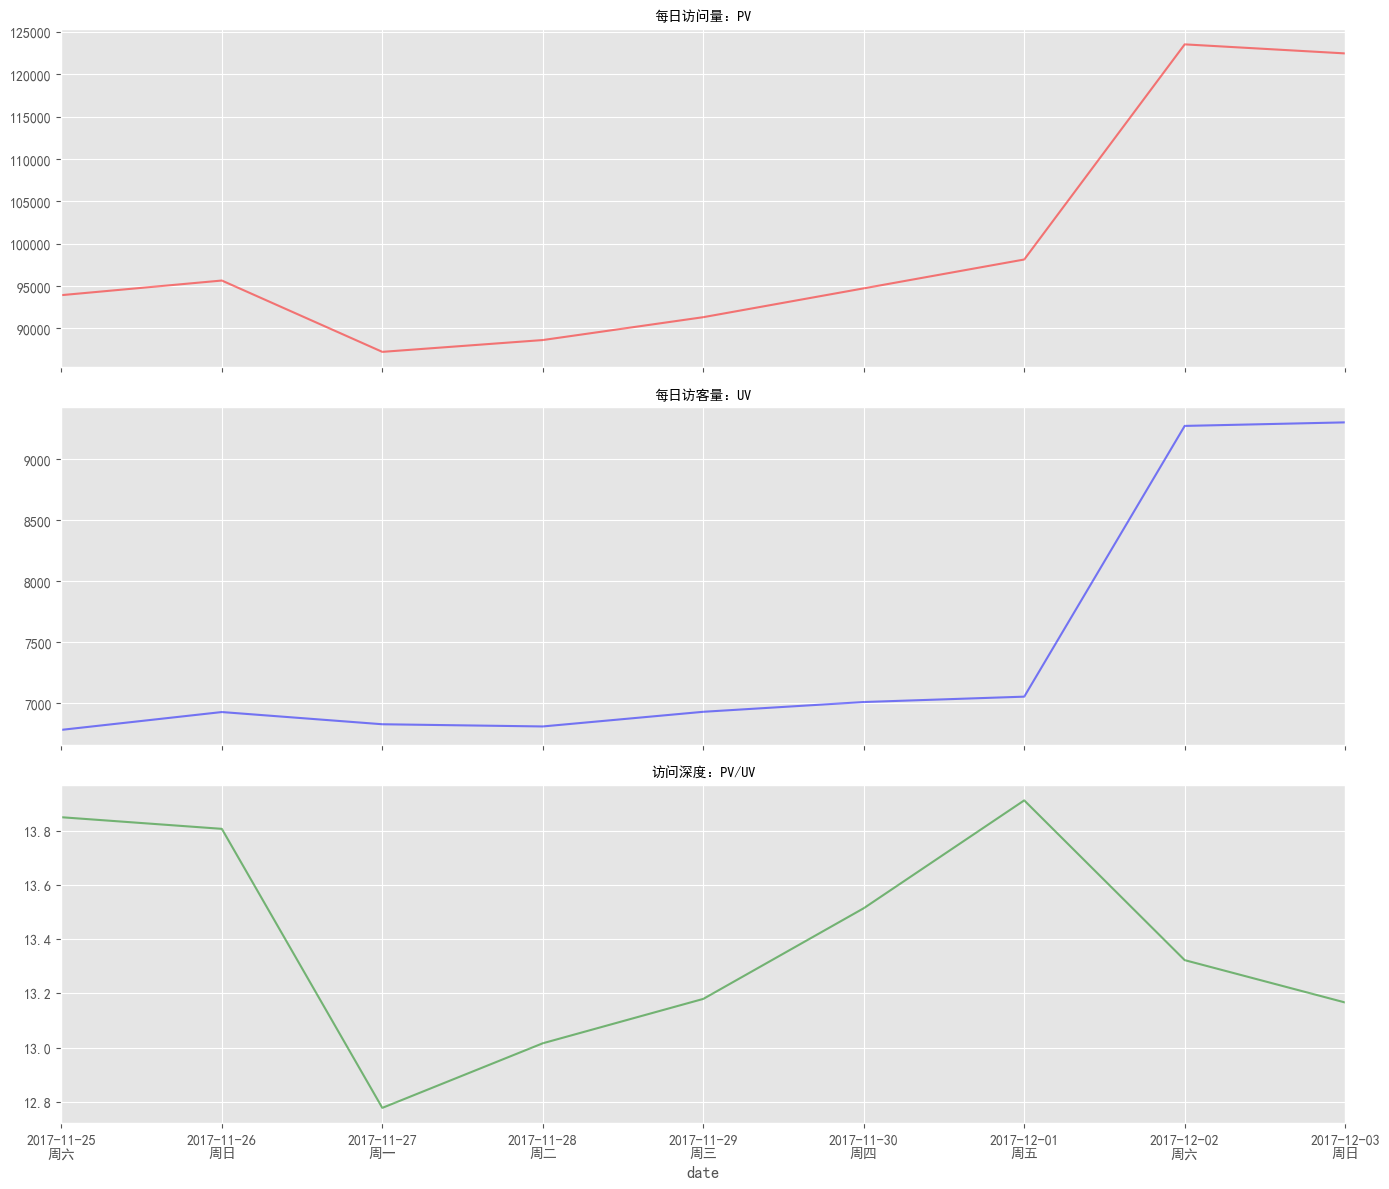

In [18]:
# 绘制每天流量趋势折线图
fig,ax=plt.subplots(3,1,figsize=(14,12),sharex=True)
date_pv.plot(ax=ax[0],color='r',alpha=0.5,fontsize=10)
date_uv.plot(ax=ax[1],color='b',alpha=0.5,fontsize=10)
date_pv_uv.plot(ax=ax[2],color='g',alpha=0.5,fontsize=10)

ax[0].set_title('每日访问量：PV',fontsize=10)
ax[1].set_title('每日访客量：UV',fontsize=10)
ax[2].set_title('访问深度：PV/UV',fontsize=10)

# 设置x轴的刻度和双层标签
weekday={1:'周一',2:'周二',3:'周三',4:'周四',5:'周五',6:'周六',7:'周日'}
labels=[f'{i.strftime('%Y-%m-%d')}\n{weekday[i.weekday()+1]}' for i in date_uv.index]
plt.xticks(ticks=date_uv.index,labels=labels,fontsize=10,rotation=0)
plt.tight_layout()
plt.show()

### 3.2、小时PV和UV趋势

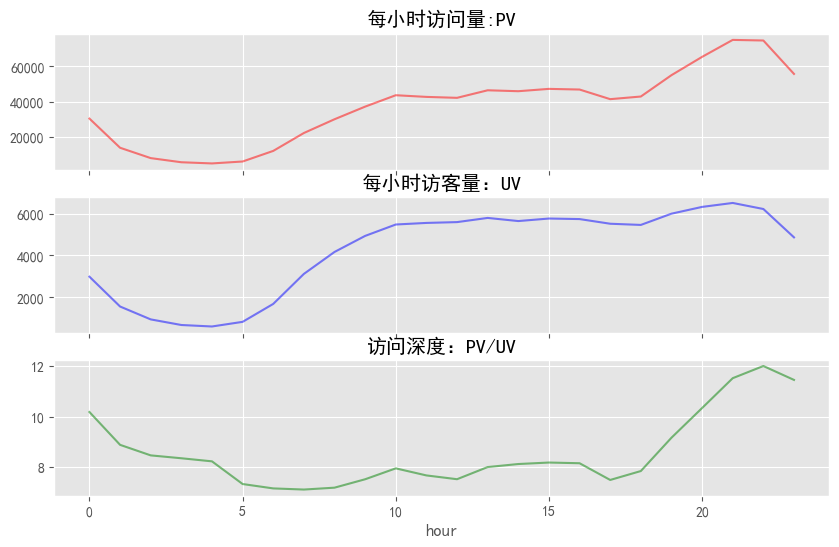

In [19]:
hour_pv=df[df['type']=='pv'].groupby('hour')['user_id'].count()
hour_uv=df[df['type']=='pv'].groupby('hour')['user_id'].nunique()
hour_pv_uv=hour_pv/hour_uv

# 绘制小时流量趋势折线图
fig, ax = plt.subplots(3, 1, figsize=(10, 6), sharex=True)

hour_pv.plot(ax=ax[0],color='r',alpha=0.5,fontsize=10)
hour_uv.plot(ax=ax[1],color='b',alpha=0.5,fontsize=10)
hour_pv_uv.plot(ax=ax[2],color='g',alpha=0.5,fontsize=10)

ax[0].set_title('每小时访问量:PV')
ax[1].set_title('每小时访客量：UV')
ax[2].set_title('访问深度：PV/UV')
plt.show()

### 3.3、每天/小时的PV和UV趋势

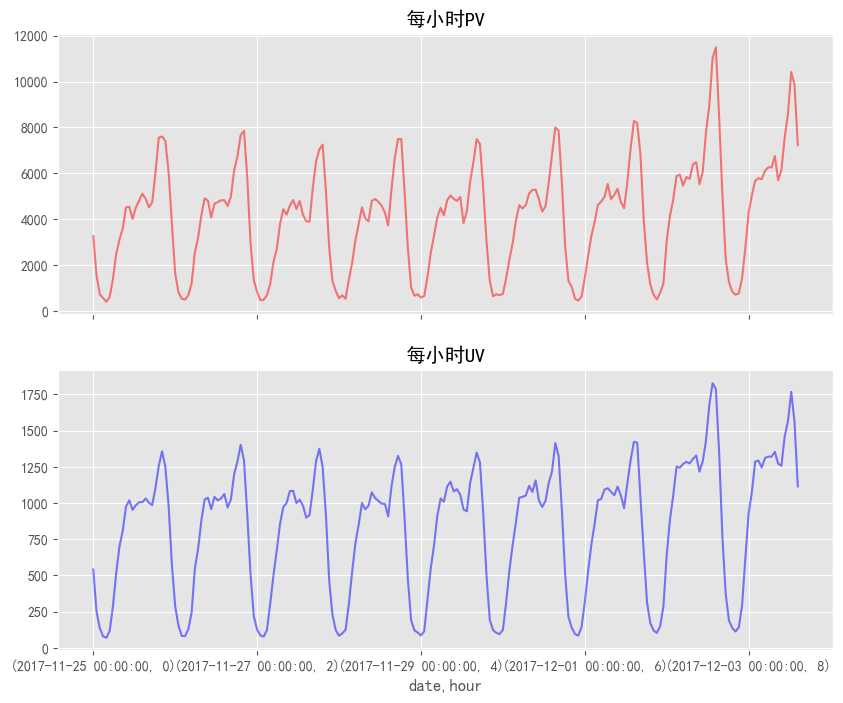

In [20]:

date_hour_pv=df[df['type']=='pv'].groupby(['date','hour'])['user_id'].count()
date_hour_uv=df[df['type']=='pv'].groupby(['date','hour'])['user_id'].nunique()

fig,ax=plt.subplots(2,1,figsize=[10,8],sharex=True)

date_hour_pv.plot(ax=ax[0],color='r',alpha=0.5,fontsize=10)
date_hour_uv.plot(ax=ax[1],color='b',alpha=0.5,fontsize=10)

ax[0].set_title('每小时PV')
ax[1].set_title('每小时UV')
plt.show()

### 3.4、 双12期间与平时流量对比

In [21]:

df_usu=df[(df['date']>='2017-11-25')&(df['date']<='2017-11-30')]  #平时数据
df_12=df[(df['date']>='2017-12-01') & (df['date']<='2017-12-03')]  #双12数据

# 双12流量
date_pv_12=date_pv[(date_pv.index>='2017-12-01 00:00:00')&(date_pv.index<='2017-12-03 23:59:59')].mean()
date_uv_12=date_uv[(date_pv.index>='2017-12-01 00:00:00')&(date_pv.index<='2017-12-03 23:59:59')].mean()

hour_pv_12=(df[(df['type']=='pv')&(df['date']>='2017-12-01 00:00:00')&(df['date']<='2017-12-03 00:00:00')].groupby('hour')['user_id'].count()/df_12['date'].nunique()).mean()

hour_uv_12=(df[(df['type']=='pv')&(df['date']>='2017-12-01 00:00:00')&(df['date']<='2017-12-03 00:00:00')].groupby('hour')['user_id'].nunique()/df_12['date'].nunique()).mean()

# 平时流量
date_pv_usu=date_pv[(date_pv.index>='2017-11-25 00:00:00')&(date_pv.index<='2017-12-03 23:59:59')].mean()
date_uv_usu=date_uv[(date_pv.index>='2017-11-25 00:00:00')&(date_pv.index<='2017-12-03 23:59:59')].mean()

hour_pv_usu=(df[(df['type']=='pv')&(df['date']>='2017-11-25 00:00:00')&(df['date']<='2017-11-30 00:00:00')].groupby('hour')['user_id'].count()/df_usu['date'].nunique()).mean()
hour_uv_usu=(df[(df['type']=='pv')&(df['date']>='2017-11-25 00:00:00')&(df['date']<='2017-11-30 00:00:00')].groupby('hour')['user_id'].nunique()/df_usu['date'].nunique()).mean()

# 活动期间与非活动期间的流量对比
date_pv_pct=(date_pv_12-date_pv_usu)/date_pv_usu
date_uv_pct=(date_uv_12-date_uv_usu)/date_uv_usu

hour_pv_pct=(hour_pv_12-hour_pv_usu)/hour_pv_usu
hour_uv_pct=(hour_uv_12-hour_uv_usu)/hour_uv_usu

### 3.5、双12活动期间与非活动期间的流量趋势折线图对比

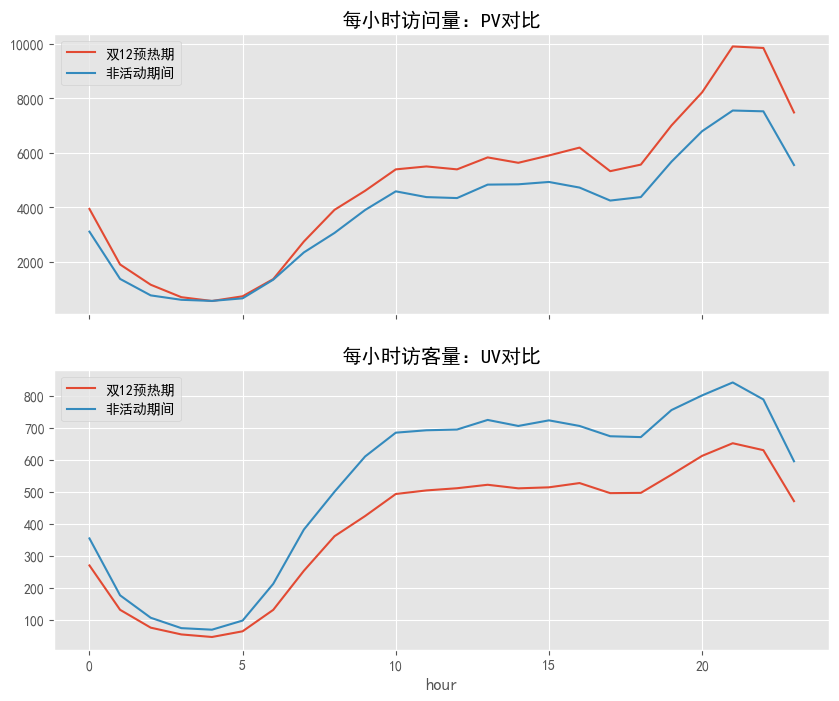

In [22]:
# PV对比
fig,ax=plt.subplots(2,1,figsize=[10,8],sharex=True)

hour_pv_1=df_12[df_12['type']=='pv'].groupby('hour')['user_id'].count()/df_12['date'].nunique()
hour_pv_1.plot(ax=ax[0],label='双12预热期')

hour_pv_2=df_usu[df_usu['type']=='pv'].groupby('hour')['user_id'].count()/df_usu['date'].nunique()
hour_pv_2.plot(ax=ax[0],label='非活动期间')

ax[0].set_title('每小时访问量：PV对比')
ax[0].legend()

# UV对比
hour_uv_1=df_12[df_12['type']=='pv'].groupby('hour')['user_id'].nunique()/df_usu['date'].nunique()
hour_uv_1.plot(ax=ax[1],label='双12预热期')

hour_uv_2=df_usu[df_usu['type']=='pv'].groupby('hour')['user_id'].nunique()/df_usu['date'].nunique()
hour_uv_2.plot(ax=ax[1],label='非活动期间')


ax[1].set_title('每小时访客量：UV对比')
ax[1].legend()

plt.show()

In [23]:
print(f' 3.1、 流量分析信息如下：'
  f'\n非活动：每日平均PV：{round(date_pv_usu,2)},每日平均UV：{round(date_uv_usu,2)};'
  f'\n双12预热期：每日平均PV：{round(date_pv_12,2)},每日平均UV：{round(date_uv_12,2)};'
  f'\n双12每日PV对比平时提升：{round(100*date_pv_pct,2)}% 每日UV对比平时提升：{round(100*date_uv_pct,2)}%\n;'

  f'\n非活动：小时平均PV：{round(hour_pv_usu,2)},小时平均UV：{round(hour_uv_usu,2)};'
  f'\n双12预热期：小时平均PV：{round(hour_pv_usu,2)},小时平均UV：{round(hour_uv_12,2)}'
  f'\n双12小时PV对比平时提升：{round(100*hour_pv_pct,2)} %小时UV对比平时提升：{round(100*hour_uv_pct,2)}%\n'
    )

 3.1、 流量分析信息如下：
非活动：每日平均PV：99515.11,每日平均UV：7434.78;
双12预热期：每日平均PV：114699.33,每日平均UV：8541.67;
双12每日PV对比平时提升：15.26% 每日UV对比平时提升：14.89%
;
非活动：小时平均PV：3830.12,小时平均UV：526.4;
双12预热期：小时平均PV：3830.12,小时平均UV：774.69
双12小时PV对比平时提升：24.78 %小时UV对比平时提升：47.17%



In [24]:
print(f' 3.2、用户访问深度：\n'
  f'每日：用户平均访问{round(date_pv_uv.mean(),2)}次；\n'
        f'每小时：用户平均访问{round(hour_pv_uv.mean(),2)}次；\n')

 3.2、用户访问深度：
每日：用户平均访问13.39次；
每小时：用户平均访问8.59次；



In [25]:
print('\n3.3、从每日流量趋势看出，呈现明显的日周期性波动：\n',
      '1、PV和UV趋势整体一致，两者变化波动都有一定周期性；周末通常高于工作日，周六和周日波动考虑家庭休闲活动影响访问；\n',
      '2、12.2开始PV和UV提升明显，可能是电商平台双12的提前活动预热；\n',
      '3、PV/UV比率趋势波动明显，周一数据直线下滑，周一到周五逐步上升，用户可能开始放松，访问模式逐渐过渡；周末明显高于工作日，可以理解是客户在周末有更多的时间浏览电商平台；\n',
      '4、双12活动期间对比平时的流量增加明显，活动有效增加了网站的访问量和访客量，尤其访客量对比非活动期间提升明显；',
      '5、双12期间，PV/UV比率下降，考虑是活动吸引了大批新客或回流客户，唤醒潜水客户，但PV相对UV又没有明显增加，故用户访问深度下降；')



3.3、从每日流量趋势看出，呈现明显的日周期性波动：
 1、PV和UV趋势整体一致，两者变化波动都有一定周期性；周末通常高于工作日，周六和周日波动考虑家庭休闲活动影响访问；
 2、12.2开始PV和UV提升明显，可能是电商平台双12的提前活动预热；
 3、PV/UV比率趋势波动明显，周一数据直线下滑，周一到周五逐步上升，用户可能开始放松，访问模式逐渐过渡；周末明显高于工作日，可以理解是客户在周末有更多的时间浏览电商平台；
 4、双12活动期间对比平时的流量增加明显，活动有效增加了网站的访问量和访客量，尤其访客量对比非活动期间提升明显； 5、双12期间，PV/UV比率下降，考虑是活动吸引了大批新客或回流客户，唤醒潜水客户，但PV相对UV又没有明显增加，故用户访问深度下降；


In [26]:
print('3.4、\n从每小时流量趋势看出，PV和UV整体趋势依然一致，访问深度也存在周期性波动：\n',
      '1、18点开始，PV和UV都上升趋势,尤其PV直线提升，PV/UV比率提升明显，该时间普遍是下班/放学时间，用户有更多时间浏览电商平台购物；\n',
      '2、22点后PV开始下降明显，22点到早上5点PV/UV持续降低，用户陆续休息；\n',
      '3、5点后PV和UV逐渐上升，用户早起，UV增加明显，但PV相对UV提升不多，用户访问深度依然下降趋势；\n',
      '4、10点开始达到流量小高峰，10点到18点PV和UV曲线平稳，波动不明显，浏览电商平台时间较少；')

3.4、
从每小时流量趋势看出，PV和UV整体趋势依然一致，访问深度也存在周期性波动：
 1、18点开始，PV和UV都上升趋势,尤其PV直线提升，PV/UV比率提升明显，该时间普遍是下班/放学时间，用户有更多时间浏览电商平台购物；
 2、22点后PV开始下降明显，22点到早上5点PV/UV持续降低，用户陆续休息；
 3、5点后PV和UV逐渐上升，用户早起，UV增加明显，但PV相对UV提升不多，用户访问深度依然下降趋势；
 4、10点开始达到流量小高峰，10点到18点PV和UV曲线平稳，波动不明显，浏览电商平台时间较少；


## 四、用户行为分析

### 4.1 、用户行为分析

#### 4.1.1 用户行为类型趋势分析

([<matplotlib.axis.XTick at 0x2b6fba00690>,
 [Text(17495, 0, '2017-11-25\n周六'),
  Text(17496, 0, '2017-11-26\n周日'),
  Text(17497, 0, '2017-11-27\n周一'),
  Text(17498, 0, '2017-11-28\n周二'),
  Text(17499, 0, '2017-11-29\n周三'),
  Text(17500, 0, '2017-11-30\n周四'),
  Text(17501, 0, '2017-12-01\n周五'),
  Text(17502, 0, '2017-12-02\n周六'),
  Text(17503, 0, '2017-12-03\n周日')])

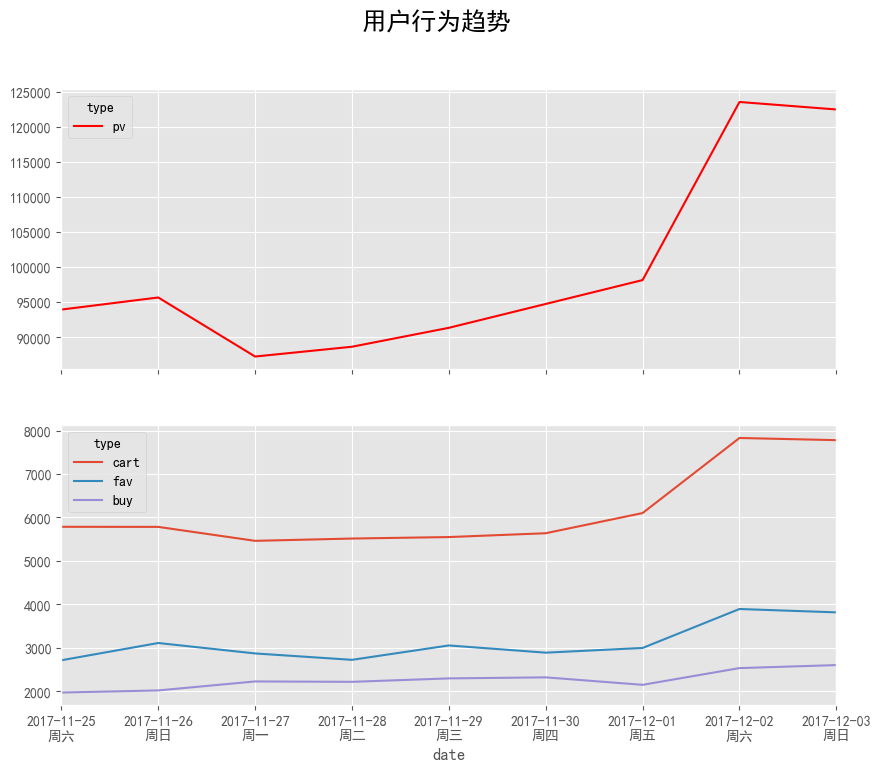

In [27]:
df_behavior=df.groupby(['date','type'])['user_id'].count().unstack() # 用户行为表

# 创建用户行为折线图
fig,ax=plt.subplots(2,1,figsize=[10,8],sharex=True)
fig.suptitle('用户行为趋势',fontsize=18,fontweight='bold')

# 因为PV量级较大，与其他行为分开绘制
df_behavior[['pv']].plot(ax=ax[0],color='r')
df_behavior[['cart','fav','buy']].plot(ax=ax[1])

# 设置x轴的双层标签，显示出星期
weekday={1:'周一',2:'周二',3:'周三',4:'周四',5:'周五',6:'周六',7:'周日'}
labels=[ f'{i.strftime('%Y-%m-%d')}\n{weekday[i.weekday()+1]}' for i in df_behavior.index]
plt.xticks(ticks=df_behavior.index,labels=labels,fontsize=10,rotation=0)

In [28]:
print('\n4.1.1、用户行为分析')
print('4.1.1、用户行为类型趋势分析：')
print('用户行为类型趋势分析，双12活动预热使用户PV提升明显，cart加购量也上升趋势，而fav收藏量和buy购买量提升幅度相对较低；\n',
      '可能有以下几个原因：\n',
      '1、用户处于观望期；双12活动预热，暂未到正式活动期，用户更多的是在进行浏览和加购，可能是在等待更低的价格、更大的优惠券或凑单满减；\n',
      '2、预热期策略影响；预热期重点推“加购有礼”，“收藏送券”等活动，鼓励客户加购而非购买；\n',
      '3、预热期部分商品仅为“预售”状态，用户只能加购，正式期才能付款；')


4.1.1、用户行为分析
4.1.1、用户行为类型趋势分析：
用户行为类型趋势分析，双12活动预热使用户PV提升明显，cart加购量也上升趋势，而fav收藏量和buy购买量提升幅度相对较低；
 可能有以下几个原因：
 1、用户处于观望期；双12活动预热，暂未到正式活动期，用户更多的是在进行浏览和加购，可能是在等待更低的价格、更大的优惠券或凑单满减；
 2、预热期策略影响；预热期重点推“加购有礼”，“收藏送券”等活动，鼓励客户加购而非购买；
 3、预热期部分商品仅为“预售”状态，用户只能加购，正式期才能付款；


#### 4.1.2 用户行为组合构成

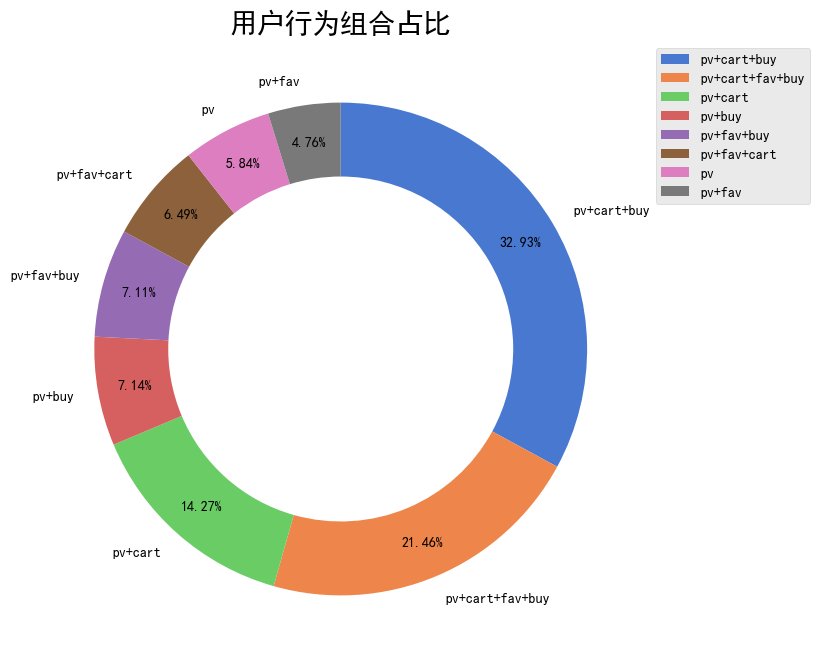

In [29]:
df_user=df.groupby(['user_id','type']).size().unstack() # 用户行为分组
df_user=df_user.reindex(columns=['pv','fav','cart','buy']) # 重置列索引的顺序

# 只分析有浏览PV行为的用户；基于本数据集只是9天数据，可能改时间段之前有浏览行为，故剔除没有PV的用户
df_user=df_user[df_user['pv'].notna()]

# 将空值替换为0，其他值替换1
df_user_status=df_user.map(lambda x:0 if pd.isna(x) else 1)
# 创建行为组合字典
behavior_combine={
  '1000':'pv',
  '1100':'pv+fav',
  '1010':'pv+cart',
  '1001':'pv+buy',
  '1110':'pv+fav+cart',
  '1011':'pv+cart+buy',
  '1101':'pv+fav+buy',
  '1111':'pv+cart+fav+buy',
}
# 各行为组合转换成组合状态并值计数
type_status=df_user_status.apply(lambda x:''.join(map(str,x)),axis=1).map(behavior_combine)
type_status=type_status.value_counts().sort_values(ascending=False)

#绘制各行为组合占比的环形图
fig,ax=plt.subplots(figsize=(10,8))

type_status.plot(kind='pie',wedgeprops=dict(width=0.3),autopct='%1.2f%%', # 绘制环形图，设置数据标签样式
startangle=90,counterclock=False,pctdistance=0.85,ax=ax,colors=sns.color_palette('muted',8)) # 开始角度90度，顺时针方向，数据标签距离

plt.axis('off')  # 隐藏坐标轴，防止坐标轴出现NOne
plt.legend(loc='upper left',bbox_to_anchor=(1,1))
plt.title('用户行为组合占比',fontsize=20)
plt.show()

In [30]:
print('\n4.1.2、用户行为组合分析：')

print('1、用户行为组合中，"pv+cart+buy"是核心转化路径，占比32.93%，是行为组合中占比最高；\n',
      '2、"pv+fav+cart+buy"深度行为组合占比达21.46%；这类用户决策更谨慎且用户群体规模较大；\n',
      '3、单一行为的pv,即仅浏览的用户行为较少，占比为5.84%；说明用户不会仅停留在浅行为阶段，浏览后通常都会进一步转化为加购或购买；\n',
      '4、"加购"是关键行为；包含加购行为组合总占比高达75.15%，加购是连接浏览和购买的核心行为；\n',
      '5、"收藏"意向不强；"pv+fav+buy"和"pv+fav"占比分别为7.11%和4.76%，从fav到buy的转化链路还需加强；\n')

print('针对以上分析总结给出运营优化建议：\n',
      '1、优化购物车功能：加购24小时未购买发送优惠券或购物车商品限时特价；购物车降价提醒；购物车凑单满减提醒；\n',
      '2、收藏夹激活：收藏商品降价提醒；收藏夹专属优惠券；收藏商品库存紧张提醒；\n',
      '3、简化购买路径：热门商品显眼"立即购买"按钮；老用户地址和支付方式记忆；倒计时优惠；库存紧张提示；')


4.1.2、用户行为组合分析：
1、用户行为组合中，"pv+cart+buy"是核心转化路径，占比32.93%，是行为组合中占比最高；
 2、"pv+fav+cart+buy"深度行为组合占比达21.46%；这类用户决策更谨慎且用户群体规模较大；
 3、单一行为的pv,即仅浏览的用户行为较少，占比为5.84%；说明用户不会仅停留在浅行为阶段，浏览后通常都会进一步转化为加购或购买；
 4、"加购"是关键行为；包含加购行为组合总占比高达75.15%，加购是连接浏览和购买的核心行为；
 5、"收藏"意向不强；"pv+fav+buy"和"pv+fav"占比分别为7.11%和4.76%，从fav到buy的转化链路还需加强；

针对以上分析总结给出运营优化建议：
 1、优化购物车功能：加购24小时未购买发送优惠券或购物车商品限时特价；购物车降价提醒；购物车凑单满减提醒；
 2、收藏夹激活：收藏商品降价提醒；收藏夹专属优惠券；收藏商品库存紧张提醒；
 3、简化购买路径：热门商品显眼"立即购买"按钮；老用户地址和支付方式记忆；倒计时优惠；库存紧张提示；


#### 4.1.3 用户行为转化

In [31]:
df_user_cvr=df_user.map(lambda x:0 if pd.isna(x) else x) #用户行为转化表，空值替换成0

# 计算用户行为转化率，因为购买的额路径可能是pv-buy,不考虑cart-buy和fav-buy转换率
pv_cart_cvr=df_user_cvr.sum()['cart']/df_user_cvr.sum()['pv']
pv_fav_cvr=df_user_cvr.sum()['fav']/df_user_cvr.sum()['pv']
pv_buy_cvr=df_user_cvr.sum()['buy']/df_user_cvr.sum()['pv']
cart_buy_cvr=df_user_cvr.sum()['buy']/df_user_cvr.sum()['cart']

In [32]:
print('\n 4.1.3、用户行为转化分析')

print(f'用户"浏览-加购"的转化率为:{pv_cart_cvr*100:.2f}%\n'
      f'用户"浏览-收藏"的转化率为:{pv_fav_cvr*100:.2f}%\n'
      f'用户"浏览-购买"的转化率为:{pv_buy_cvr*100:.2f}%\n'
      f'用户"加购-购买"的转化率为:{cart_buy_cvr*100:.2f}%\n')


 4.1.3、用户行为转化分析
用户"浏览-加购"的转化率为:6.15%
用户"浏览-收藏"的转化率为:3.11%
用户"浏览-购买"的转化率为:2.26%
用户"加购-购买"的转化率为:36.65%



In [33]:
print('由用户转化漏斗数据可知：\n',
      '1、转化漏斗衰减明显，93.85%用户浏览后无加购；96.89%用户浏览后无收藏；\n',
      '2、"加购-购买"转化不足，加购用户中仅36.65%最终购买且实际数据比该值还低；\n',

      '给出优化建议：\n',
      '1、提高加购率：加购率低可能原因价格缺乏竞争力；商品主图/详情页不够吸引，设置适宜价格和提升产品视觉美观；',
        '加购按钮旁显示"已有XX人加购"；首次加购送优惠券；\n'
      '2、提高收藏率：收藏按钮更显眼；收藏后享专属优惠；\n',
      '3、提高"加购-购买"转化率：购物车满减优惠、限时优惠、降价提醒等；购物车库存紧张提示；加购后24小时未购买推送提醒;\n')

由用户转化漏斗数据可知：
 1、转化漏斗衰减明显，93.85%用户浏览后无加购；96.89%用户浏览后无收藏；
 2、"加购-购买"转化不足，加购用户中仅36.65%最终购买且实际数据比该值还低；
 给出优化建议：
 1、提高加购率：加购率低可能原因价格缺乏竞争力；商品主图/详情页不够吸引，设置适宜价格和提升产品视觉美观； 加购按钮旁显示"已有XX人加购"；首次加购送优惠券；
2、提高收藏率：收藏按钮更显眼；收藏后享专属优惠；
 3、提高"加购-购买"转化率：购物车满减优惠、限时优惠、降价提醒等；购物车库存紧张提示；加购后24小时未购买推送提醒;



In [34]:
# 双12活动预热期与平时的转化对比

# 新建is_2列，判断是否是双12活动并分组聚合
df['is_12']=((df['date']>='2017-11-25')&(df['date']<='2017-11-30')).map({True: 'no',False: 'yes'})

# 新建列，来计算转化率
df_12=df.groupby(['is_12','type']).size().unstack().reindex(columns=['pv','fav','cart','buy'])
df_12['pv_cart_cvr']=df_12['cart']*100/df_12['pv'].round(2)
df_12['pv_fav_cvr']=df_12['fav']*100/df_12['pv'].round(2)
df_12['cart_buy_cvr']=df_12['buy']*100/df_12['cart'].round(2)

In [35]:
print(f'双12活动预热期与平时对比数据如下：\n{df_12}')

print(f'●双12活动预热期的"浏览-加购"、"浏览-收藏"的转化率对比平时变化不明显，其中"浏览-加购"略有提升；\n'
      f'●双12活动预热期的"加购-购买"转化率低于平时转化率；\n'
      f'●该现象与用户行为趋势分析一致，双12活动预热期用户的浏览和加购行为前置，加购率高于平时；\n'
      f'●而用户购买行为可能后置到正式双12活动，故在双12预热期购买率低于平时；\n')

双12活动预热期与平时对比数据如下：
type       pv    fav   cart    buy  pv_cart_cvr  pv_fav_cvr  cart_buy_cvr
is_12                                                                    
no     551538  17376  33737  13067     6.116895    3.150463     38.731956
yes    344098  10712  21710   7292     6.309249    3.113067     33.588208
●双12活动预热期的"浏览-加购"、"浏览-收藏"的转化率对比平时变化不明显，其中"浏览-加购"略有提升；
●双12活动预热期的"加购-购买"转化率低于平时转化率；
●该现象与用户行为趋势分析一致，双12活动预热期用户的浏览和加购行为前置，加购率高于平时；
●而用户购买行为可能后置到正式双12活动，故在双12预热期购买率低于平时；



### 4.2、用户价值分析

#### 4.2.1、 用户购买频次分析

In [36]:
print('4.2.1、用户购买频次分析')
buy_count=df[df['type']=='buy'].groupby('user_id')['type'].count()

# 计算购买用户占比
buy_user_pct=len(buy_count)/df['user_id'].nunique()
print(f'活跃用户中购买用户占比为：{buy_user_pct*100:.2f}%; 其中购买用户数为：{len(buy_count)};')

buy_1=len(buy_count[buy_count.values==1])/len(buy_count)
print(f'活跃用户中购买用户占比为：{buy_1*100:.2f}%; 购买用户再复购占比为：{100-100*buy_1:.2f}%')

# 计算平均购买频次以及仅购买一次用户占比
active_user_buy=buy_count.values.sum()/df['user_id'].nunique()

print(f'活跃用户的平均购买次数为：{active_user_buy:.2f}次')
print(f'购买用户的平均购买次数为：{buy_count.values.mean():.2f}次')

4.2.1、用户购买频次分析
活跃用户中购买用户占比为：68.68%; 其中购买用户数为：6689;
活跃用户中购买用户占比为：33.79%; 购买用户再复购占比为：66.21%
活跃用户的平均购买次数为：2.09次
购买用户的平均购买次数为：3.04次


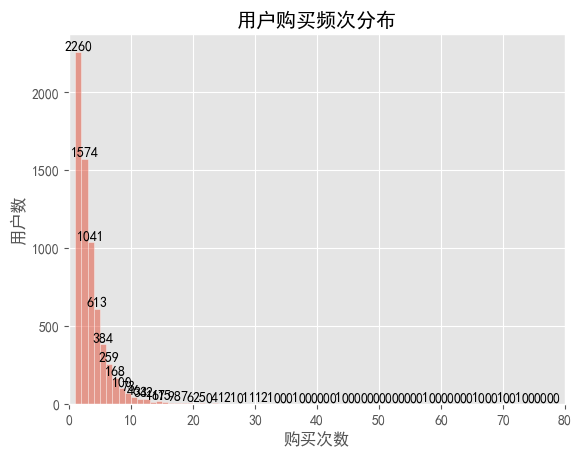

In [37]:
# 购买频次的直方图分布
fig,ax=plt.subplots()

plt.hist(buy_count,bins=range(1,80),alpha=0.5,edgecolor='white',linewidth=0.5)
# 添加数据标签
ax.bar_label(ax.containers[0])

plt.title('用户购买频次分布')
plt.ylabel('用户数')
plt.xlabel('购买次数')
plt.xlim([0,80])
plt.show()

In [38]:
print('\n购买转化与复购表现：\n',
      '1、活跃用户中近7成（68.68%）完成购买，说明活跃用户的消费转化意愿较强；\n',
      '2、购买用户中，复购用户超6成（66.21%），复购基础好；\n',
      '3、活跃用户平均购买2.09次，购买用户平均3.04次，体现复购用户对整体频次的拉升作用；\n',

      '\n用户消费频次分布特征：\n'
      '1、购买频次呈幂律分布；低频次用户占主导，消费(1-3)次用户占比达72.88%，大部分的用户消费次数仅在3次及以下；',
          '针对仅购买1次用户，可通过“首单后触达”（如复购优惠券，个性化商品推荐）降低决策门槛，推动其二次购买转化；',
          '（2-10）次的低频次复购人群，可设计“阶梯式激励”（如购买次数越多优惠越大），引导其提升购买频次；\n',
      '2、消费次数在10次以上的用户数递减，总用户占比仅2.56%，长尾效应明显，高频复购人群基数小；',
          '高频次用户需提供专属权益（如VIP服务，定制化服务）强化留存，同时挖掘拉新潜力，放大影响力；\n')


购买转化与复购表现：
 1、活跃用户中近7成（68.68%）完成购买，说明活跃用户的消费转化意愿较强；
 2、购买用户中，复购用户超6成（66.21%），复购基础好；
 3、活跃用户平均购买2.09次，购买用户平均3.04次，体现复购用户对整体频次的拉升作用；
 
用户消费频次分布特征：
1、购买频次呈幂律分布；低频次用户占主导，消费(1-3)次用户占比达72.88%，大部分的用户消费次数仅在3次及以下； 针对仅购买1次用户，可通过“首单后触达”（如复购优惠券，个性化商品推荐）降低决策门槛，推动其二次购买转化； （2-10）次的低频次复购人群，可设计“阶梯式激励”（如购买次数越多优惠越大），引导其提升购买频次；
 2、消费次数在10次以上的用户数递减，总用户占比仅2.56%，长尾效应明显，高频复购人群基数小； 高频次用户需提供专属权益（如VIP服务，定制化服务）强化留存，同时挖掘拉新潜力，放大影响力；



#### 4.2.2用户购买周期分析

In [39]:
#取购买行为数据并按日期去重
df_buy=df[df['type']=='buy'].drop_duplicates(subset=['user_id','date'],keep='first')

buy_day=df_buy.groupby('user_id')['date'].apply(lambda x:x.sort_values().diff(1).dropna()).dt.days
buy_day=buy_day.reset_index(name='buy_day_diff')

print('\n4.2.2、用户购买周期分析')

print(f'用户平均购买周期为：{buy_day.buy_day_diff.mean():.2f}天')


4.2.2、用户购买周期分析
用户平均购买周期为：2.39天


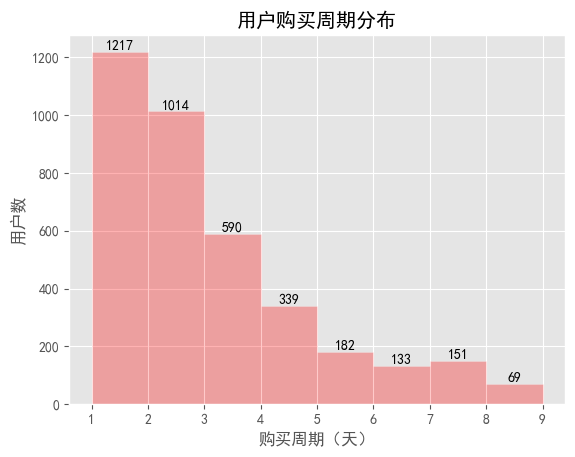

In [40]:
# 用户购买周期分布
buy_day=buy_day.groupby('user_id')['buy_day_diff'].mean()

fig,ax=plt.subplots()

plt.hist(buy_day,bins=range(1,10),color='red',alpha=0.3,edgecolor='white',linewidth=0.5)

ax.bar_label(ax.containers[0])
plt.title('用户购买周期分布')
plt.xlabel('购买周期（天）')
plt.ylabel('用户数')
plt.show()


In [41]:
print('由用户购买周期分布可知：\n',
      '1、购买周期为（1-2）天用户数占比60.38%，超一半用户的消费周期在2天内；',
         '这类用户复购意愿强，可推出专属权益（如多买多返券，积分翻倍），进一步强化复购习惯，同时引导向更高客单价转化；\n',
      '2、周期越长，用户数整体递减；随着购买周期3天到8天的延伸，用户数量整体呈下降趋势，仅7天周期用户数略有回升；',
          '针对购买周期（3-4）天的用户，需通过精准触达（如个性化商品推荐和复购提醒）缩短购买周期，避免流失；\n',
      '3、长周期用户基数少，购买周期在5天以上的用户数均低于200，属于低频复购群体；该类用户复购动力弱，可设计唤醒活动（如专属折扣或新品使用福利），刺激再次消费；\n')

由用户购买周期分布可知：
 1、购买周期为（1-2）天用户数占比60.38%，超一半用户的消费周期在2天内； 这类用户复购意愿强，可推出专属权益（如多买多返券，积分翻倍），进一步强化复购习惯，同时引导向更高客单价转化；
 2、周期越长，用户数整体递减；随着购买周期3天到8天的延伸，用户数量整体呈下降趋势，仅7天周期用户数略有回升； 针对购买周期（3-4）天的用户，需通过精准触达（如个性化商品推荐和复购提醒）缩短购买周期，避免流失；
 3、长周期用户基数少，购买周期在5天以上的用户数均低于200，属于低频复购群体；该类用户复购动力弱，可设计唤醒活动（如专属折扣或新品使用福利），刺激再次消费；



#### 4.2.3、用户留存率

In [42]:
# 次日留存率
retention_1=df.groupby(['date','user_id'])['type'].count().reset_index()
retention_2=df.groupby(['date','user_id'])['type'].count().reset_index()
retention=pd.merge(retention_1,retention_2,on=['user_id'],suffixes=('_1','_2'))

# 筛选次日留存记录并分组统计
retention=retention[(retention['date_2']-retention['date_1']).dt.days==1]
retention_group=retention.groupby('date_1')['user_id'].count()

# 每天的用户数
user_day=df.groupby('date')['user_id'].nunique()

# 计算次日留存率（删除空值）
user_retention_1=(retention_group/user_day).dropna().reset_index(name='retention_rate')


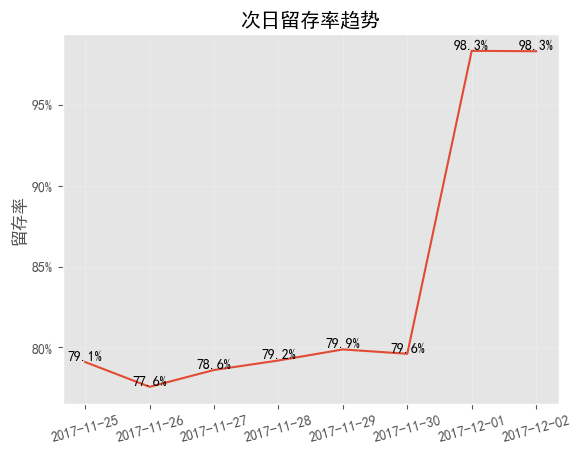

In [43]:
# 绘制次日留存率趋势折线图
fig,ax=plt.subplots()

#  核心修复：手动构造和你图里完全一致的日期标签（彻底绕开1970问题）
# 直接用你图里的日期做X轴，100%匹配
x_labels = ['2017-11-25', '2017-11-26', '2017-11-27', '2017-11-28', '2017-11-29', '2017-11-30', '2017-12-01', '2017-12-02']

# 绘图：用手动日期标签做X轴，完全不碰索引转换
plt.plot(x_labels, user_retention_1['retention_rate']*100)

plt.title('次日留存率趋势')
plt.ylabel('留存率')
plt.grid(alpha=0.2)
plt.xticks(rotation=15)

# 设置Y轴百分号标签
pct_label=ticker.FormatStrFormatter('%.0f%%')
ax.yaxis.set_major_formatter(pct_label)

# 设置折线图的数据标签（用手动日期标签做X轴，完全对应）
for i ,(x,y) in enumerate(zip(x_labels, user_retention_1['retention_rate'])):
    plt.text(x, y*100, f'{y*100:.1f}%', ha='center', va='bottom')

plt.show()

In [44]:
print('\n4.2.3、用户留存率分析\n',
      '从2017-11-25至2017-12-02的次日留存率数据可看出：\n',
      '活动前（11.25-11.30）留存率处于77.6%-79.9%的低位区间，整体波动较小，表现平稳；双12预热期（12.1-12.2）留存率陡增至98.3%,并保持稳定',
        '活动预热对次日留存的拉动效果显著；\n',
      '1、建议复用活动预热的留存策略，本次预热玩法契合用户需求，可总结运营手段复用到后续大促或节点活动中；\n',
      '2、延长活动留存周期：需跟踪双12正式及活动后的留存走势，避免预热期留存冲高后快速回落，可通过活动后长尾福利，如返场权益维持用户粘性；\n')


4.2.3、用户留存率分析
 从2017-11-25至2017-12-02的次日留存率数据可看出：
 活动前（11.25-11.30）留存率处于77.6%-79.9%的低位区间，整体波动较小，表现平稳；双12预热期（12.1-12.2）留存率陡增至98.3%,并保持稳定 活动预热对次日留存的拉动效果显著；
 1、建议复用活动预热的留存策略，本次预热玩法契合用户需求，可总结运营手段复用到后续大促或节点活动中；
 2、延长活动留存周期：需跟踪双12正式及活动后的留存走势，避免预热期留存冲高后快速回落，可通过活动后长尾福利，如返场权益维持用户粘性；



#### 4.2.4、用户RFM分层

In [45]:
#因数据集中没有消费金额维度数据，这里的M就用（PV+cart+fav)频次代替
df_user=df.groupby(['user_id','type']).size().unstack().reindex(columns=['pv','fav','cart','buy'])# 用户行为分组
df_user=df_user[(df_user['pv'].notna())&(df_user['buy'].notna())]
df_user=df_user.map(lambda x:0 if pd.isna(x) else x).reset_index()

# 获得用户购买的最近日期
df_time_max=df[df['type']=='buy'].groupby('user_id')['date'].max().reset_index()

In [46]:
# 表连接
user_rfm=pd.merge(df_user,df_time_max,on=['user_id'],how='left')
user_rfm['m']=user_rfm['pv']+user_rfm['fav']+user_rfm['cart']
user_rfm['f']=user_rfm['buy']
user_rfm['r']=(df_time_max['date'].max()-user_rfm['date']).dt.days

# rfm与对应维度的均值比较，记为1或0
rfm=user_rfm[['r','f','m']].copy()
rfm['r']=rfm['r']<=rfm['r'].mean()
rfm['f']=rfm['f']>=rfm['f'].mean()
rfm['m']=rfm['m']>=rfm['m'].mean()

rfm=rfm.map(lambda x:1 if x else 0)

In [47]:
#用户分层定义
status={#因pv+cart+fav频次代替m消费金额，所以rfm的用户分层名称需基于用户行为逻辑
    '111':'重要活跃用户',
    '110':'一般活跃用户',
    '101':'重要留存用户',
    '100':'一般留存用户',
    '011':'核心召回用户',
    '010':'一般召回用户',
    '001':'重要唤醒用户',
    '000':'一般唤醒用户'}

#用户分层统计
rfm=rfm.apply(lambda x: ''.join(map(str,x)),axis=1).map(status).value_counts()

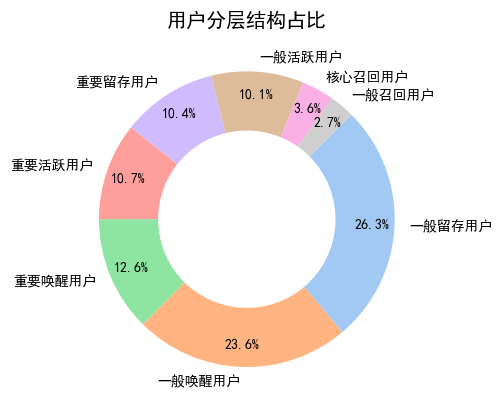

In [48]:
# 绘制环形图
fig,ax=plt.subplots()
rfm.plot(kind='pie',ax=ax,wedgeprops=dict(width=0.4),colors=sns.color_palette('pastel',8),autopct='%1.1f%%',startangle=45,counterclock=False,pctdistance=0.85)

plt.axis('off')
plt.title('用户分层结构占比')
plt.show()

In [49]:
print('\n4.2.4、用户分层结构分析\n',
      '1、一般留存用户和一般唤醒用户是占比最高的两个群体，两者占比合计接近50%，该类用户基数大但分层标签“一般”，忠诚度低，购买频次低',
          '可通过个性化运营，推低价爆款/小品类轻决策商品以及平台活动普适推送来提升活跃度;\n',
      '2、“重要类用户”中重要唤醒用户、重要活跃用户以及重要留存用户，占比相对均衡，合计33.7%；高价值潜力群体，需强化留存策略',
         '如专属权益、个性化优惠和推荐；\n',
      '3、召回用户占比低，合计仅6.3%；该类用户近期不活跃，有流失风险，优化召回触达渠道、发送上新推送或“3天内浏览得券”回归福利等；')


4.2.4、用户分层结构分析
 1、一般留存用户和一般唤醒用户是占比最高的两个群体，两者占比合计接近50%，该类用户基数大但分层标签“一般”，忠诚度低，购买频次低 可通过个性化运营，推低价爆款/小品类轻决策商品以及平台活动普适推送来提升活跃度;
 2、“重要类用户”中重要唤醒用户、重要活跃用户以及重要留存用户，占比相对均衡，合计33.7%；高价值潜力群体，需强化留存策略 如专属权益、个性化优惠和推荐；
 3、召回用户占比低，合计仅6.3%；该类用户近期不活跃，有流失风险，优化召回触达渠道、发送上新推送或“3天内浏览得券”回归福利等；


## 五、产品及品类分析

## 5.1、产品分析

产品分析


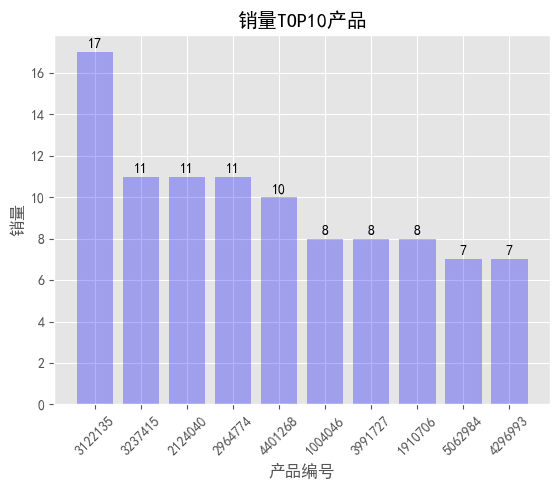

In [50]:
print('产品分析')
df_product=df.groupby(['product_id','type']).size().unstack().reindex(columns=['pv','fav','cart','buy']).sort_values('buy',ascending=False)

# 取销售量top10的产品
df_product_10=df_product[:10].copy()

# 绘制top10产品柱状图
fig,ax=plt.subplots()
#x轴是数值类型遍历为字符串
plt.bar([str(i) for i in df_product_10.index],df_product_10['buy'],color='b',alpha=0.3)
#添加数据标签
for x,y in enumerate(df_product_10['buy']):
    plt.text(x,y+0.1,f'{y:.0f}',ha='center',va='bottom')

plt.title('销量TOP10产品')
plt.xlabel('产品编号')
plt.ylabel('销量')
plt.xticks(rotation=45)
plt.show()


In [51]:
print(f'产品销量描述统计：\n{df_product.buy.describe()}')

print('\n从销量描述统计和top10产品可知，销量分布及其集中，超75%的产品销量仅为1；top1产品销量仅17，销量差距不明显；top（2-10）产品的销量相对集中（7-11）区间，内部差异小；\n',
      '1、激活低销量产品，对销量为1的产品，筛选符合用户偏好的产品，通过关联推荐（搭配高销量产品）或低价试销等方式提升曝光及转化；\n',
      '2、优化产品结构，淘汰无潜力的低销量产品；\n',
      '3、对top产品增加流量倾斜（如首页推荐、活动主会场），尝试打造为小爆款，拉动品类整体销量；\n',
      '4、分析top产品的共性特征（如价格、品类），复用成功逻辑到其他产品；\n',
      '5、优化资源配置，针对不同销量产品分层匹配差异化资源；\n')

产品销量描述统计：
count    17565.000000
mean         1.159066
std          0.546493
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         17.000000
Name: buy, dtype: float64

从销量描述统计和top10产品可知，销量分布及其集中，超75%的产品销量仅为1；top1产品销量仅17，销量差距不明显；top（2-10）产品的销量相对集中（7-11）区间，内部差异小；
 1、激活低销量产品，对销量为1的产品，筛选符合用户偏好的产品，通过关联推荐（搭配高销量产品）或低价试销等方式提升曝光及转化；
 2、优化产品结构，淘汰无潜力的低销量产品；
 3、对top产品增加流量倾斜（如首页推荐、活动主会场），尝试打造为小爆款，拉动品类整体销量；
 4、分析top产品的共性特征（如价格、品类），复用成功逻辑到其他产品；
 5、优化资源配置，针对不同销量产品分层匹配差异化资源；



### 5.2类目分析

5.2、品类分析


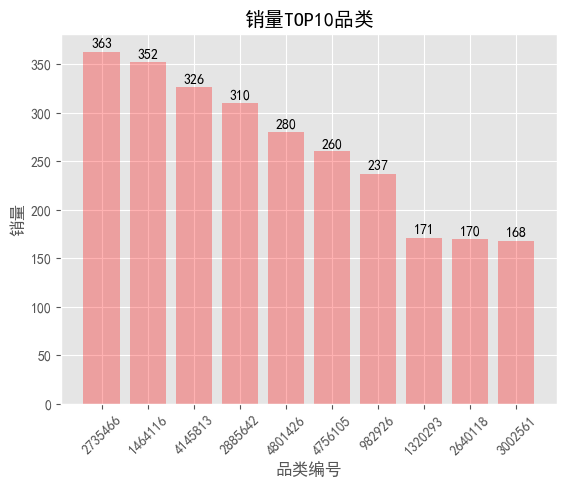

In [52]:
print('5.2、品类分析')

df_category=df.groupby(['category_id','type']).size().unstack().reindex(columns=['pv','fav','cart','buy']).sort_values('buy',ascending=False)

# 绘制销量TOP品类的柱状图
df_category_10=df_category[:10].copy()
fig,ax=plt.subplots()
# x轴是数值类型遍历为字符串
plt.bar([str(i) for i in df_category_10.index],df_category_10['buy'],color='r',alpha=0.3)

# 添加数据标签
for x,y in enumerate(df_category_10['buy']):
    plt.text(x,y+2,f'{y:.0f}',ha='center',va='bottom')

plt.title('销量TOP10品类')
plt.xlabel('品类编号')
plt.ylabel('销量')
plt.xticks(rotation=45)
plt.show()

In [53]:
print(f'品类销量描述统计：\n{df_category.buy.describe()}')

print('\n品类销量两级分化，75%分位数的品类销量为6；大多数品类处于低销量区间；均值8，标准差22.7,最大值363，体现少数头部品类高销量大幅拉高整体均值，品类间销量差异极大；\n',
      '1、对top5头部品类加大资源投入，维持高销量又是；挖掘头部类目的用户需求，拓展品类下的产品矩阵，进一步放大品类价值；\n',
      '2、针对腰部top（6-10）品类，测试流量扶持+活动激励策略，推动其向头部类目升级；\n',
      '3、激活低销量品类，筛选符合市场趋势的潜力品类，通过品类关联、精准营销等提升销量；优化品类结构，淘汰无增长潜力品类；\n',
      '4、分析top类目的成功因素（如产品特性、用户群体），将经验复用至低销量类目中；\n')

品类销量描述统计：
count    2513.000000
mean        8.101472
std        22.757629
min         1.000000
25%         1.000000
50%         2.000000
75%         6.000000
max       363.000000
Name: buy, dtype: float64

品类销量两级分化，75%分位数的品类销量为6；大多数品类处于低销量区间；均值8，标准差22.7,最大值363，体现少数头部品类高销量大幅拉高整体均值，品类间销量差异极大；
 1、对top5头部品类加大资源投入，维持高销量又是；挖掘头部类目的用户需求，拓展品类下的产品矩阵，进一步放大品类价值；
 2、针对腰部top（6-10）品类，测试流量扶持+活动激励策略，推动其向头部类目升级；
 3、激活低销量品类，筛选符合市场趋势的潜力品类，通过品类关联、精准营销等提升销量；优化品类结构，淘汰无增长潜力品类；
 4、分析top类目的成功因素（如产品特性、用户群体），将经验复用至低销量类目中；



#### 5.2.2 品类购买率top

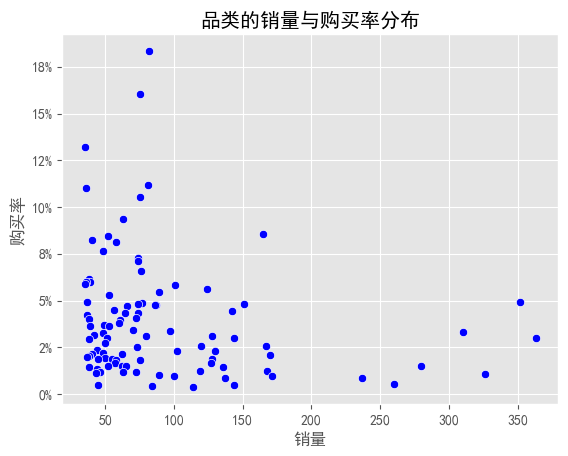

In [54]:
# 新建列，计算加购率和购买率（pv-buy），可能加购率没有购买量多，掩埋数据真实性
df_category['pv_cart_cvr']=100*df_category['cart']/df_category['pv'].round(2)
df_category['pv_buy_cvr']=100*df_category['buy']/df_category['pv'].round(2)

#切片销量前100品类
df_category_100=df_category[:100].copy() #切片后复制副本，否则可能报错

# 按购买率和加购率降序
df_category_100.sort_values(['pv_buy_cvr','pv_cart_cvr'],ascending=[False,False],inplace=True)

# 绘制销量与购买率的散点图
fig,ax=plt.subplots()
sns.scatterplot(data=df_category_100,x='buy',y='pv_buy_cvr',color='b')

# 设置Y轴坐标轴的百分号显示
pct_label=ticker.FormatStrFormatter('%.0f%%')
ax.yaxis.set_major_formatter(pct_label)

plt.title('品类的销量与购买率分布')
plt.xlabel('销量')
plt.ylabel('购买率')
plt.show()

In [55]:
print('\n5.2.2、品类销量与购买率分析：')

print(f'从品类销量与购买率分布看出，两者无明显正相关关系，未呈现同步增长的趋势，说明高销量不等价于高购买率；\n'
      f'高销量品类的购买率偏低，销量大于200的品类中，购买率普遍低于5%，高销量品类的购买转化率较弱；\n'
      f'低销量品类的购买率波动大，销量小于50的品类中，部分购买率高达12%-18%，多数集中在0-5%区间，购买率差异显著；\n'
      f'1、针对“低销量+高购买率”品类，加大流量投入，提升销量规模；分析其高购买率的原因，复用至其他低转化品类；\n'
      f'2、针对“高销量+低购买率”品类，优化转化链路，增加信任背书，提升转化；筛选品类下的高转化产品，聚焦资源推广，带动整体购买率提升；\n')


5.2.2、品类销量与购买率分析：
从品类销量与购买率分布看出，两者无明显正相关关系，未呈现同步增长的趋势，说明高销量不等价于高购买率；
高销量品类的购买率偏低，销量大于200的品类中，购买率普遍低于5%，高销量品类的购买转化率较弱；
低销量品类的购买率波动大，销量小于50的品类中，部分购买率高达12%-18%，多数集中在0-5%区间，购买率差异显著；
1、针对“低销量+高购买率”品类，加大流量投入，提升销量规模；分析其高购买率的原因，复用至其他低转化品类；
2、针对“高销量+低购买率”品类，优化转化链路，增加信任背书，提升转化；筛选品类下的高转化产品，聚焦资源推广，带动整体购买率提升；



#### 5.2.3 双12预热期对比平时的品类销量差异

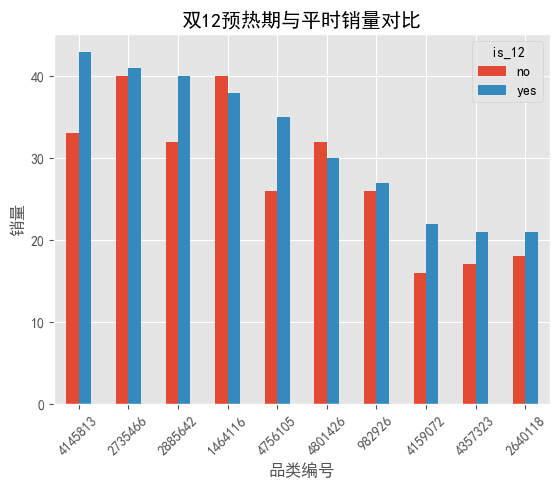

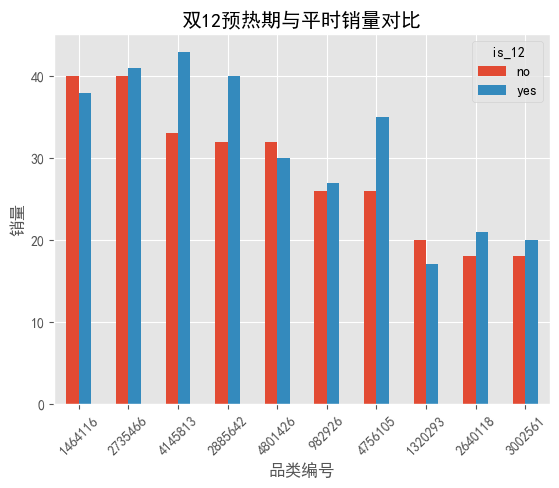

In [56]:
df['cnt']=1
top_12=pd.pivot_table(df[df['type']=='buy'],index=['category_id'],columns=['is_12'],values='cnt',aggfunc='sum')
top_12['no']=(top_12['no']/6).round(0)    #平时日均销量
top_12['yes']=(top_12['yes']/3).round(0)  #双12日均销量

top_12_12=top_12.sort_values(['yes','no'],ascending=[False,False])
top_12_usu=top_12.sort_values(['no','yes'],ascending=[False,False])

for i in ['yes','no']:
    data=top_12.sort_values([i],ascending=[False]).head(10)

    fig,ax=plt.subplots()
    data.plot(kind='bar',ax=ax)

    plt.title('双12预热期与平时销量对比')
    plt.xlabel('品类编号')
    plt.ylabel('销量')
    plt.xticks(rotation=45)
    plt.show()

In [57]:
print('5.2.3、类目销量差异分析（双12预热期与平时对比）')

print('1、多数品类预热期销量高于平时；其中4145813和4756105品类在预热期显著高于平时销量，说明活动对类目销量的拉动效果普遍有效；\n',
      ' ●针对预热期销量高增类目，加大这些品类的库存储备，避免缺货；\n',
      ' ●增加其预热期活动曝光量（增加推荐广告位），进一步放大销量增长效应；\n',
      '2、品类间的活动响应差异大，部分类目如2735466预热期与平时销量差距极小；部分类目如1464116预热期销量低于平时；活动对这些品类刺激不足；\n',
      ' ●针对低响应类目，调整活动策略，增加专属折扣、搭配赠品等展示，提升用户感知；\n',
      ' ●精准触达人群，分析这些类目的目标用户，定向推送活动信息，减少无效触达；\n',
      ' ●关联高响应品类做组合推荐，借助高热度类目带动其流量和销量；\n')

5.2.3、类目销量差异分析（双12预热期与平时对比）
1、多数品类预热期销量高于平时；其中4145813和4756105品类在预热期显著高于平时销量，说明活动对类目销量的拉动效果普遍有效；
  ●针对预热期销量高增类目，加大这些品类的库存储备，避免缺货；
  ●增加其预热期活动曝光量（增加推荐广告位），进一步放大销量增长效应；
 2、品类间的活动响应差异大，部分类目如2735466预热期与平时销量差距极小；部分类目如1464116预热期销量低于平时；活动对这些品类刺激不足；
  ●针对低响应类目，调整活动策略，增加专属折扣、搭配赠品等展示，提升用户感知；
  ●精准触达人群，分析这些类目的目标用户，定向推送活动信息，减少无效触达；
  ●关联高响应品类做组合推荐，借助高热度类目带动其流量和销量；



#### 5.2.4 类目行为分层

In [58]:
print('5.2.4、类目行为分层分析')

# 对类目的浏览、加购和收藏、购买三个维度进行类目分类；思路同RFM类似，将RFM三个维度分别替换为PV、cart/fav、buy;
df_category['cart/fav']=df_category['cart']+df_category['fav']
category_type=df_category[['pv','cart/fav','buy']].copy()

# 类目的用户行为量与中位数比较，大于等于中位数记为1，否则记为0
category_type['pv_status']=category_type['pv']>=category_type['pv'].median()
category_type['cart_fav_status']=category_type['cart/fav']>=category_type['cart/fav'].median()
category_type['buy_status']=category_type['buy']>=category_type['buy'].median()

for i in ['pv_status','cart_fav_status','buy_status']:
    category_type[i]=category_type[i].apply(lambda x:'1' if x==True else '0')

5.2.4、类目行为分层分析


In [59]:
# 定义类目分层属性，对PV、cart/fav、buy三个维度变量，将大于本维度中位数记为1否则为0
status={#pv 代表流量热度，用户关注度；cart/fav代表用户兴趣度；buy代表类目商业价值
  '111':'核心价值类目',
  '110':'潜力转化类目',
  '101':'高价值引流类目',
  '100':'基础流量类目',
  '011':'高潜力小众类目',
  '010':'兴趣培养类目',
  '001':'长尾营收类目',
  '000':'待激活类目'
 }

category_type['type_3']=category_type['pv_status']+category_type['cart_fav_status']+category_type['buy_status']
category_type['type_3']=category_type['type_3'].map(status)

# 类目分层计数统计
category_status=category_type['type_3'].value_counts().sort_values(ascending=False)

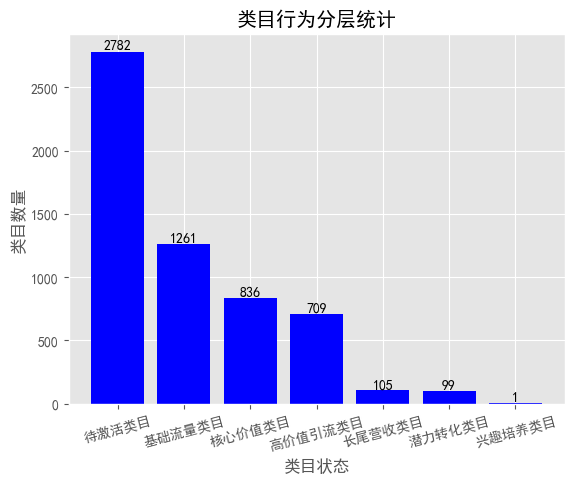

In [60]:
# 绘制类目行为分层柱状图
fig,ax=plt.subplots()
bar2=plt.bar(category_status.index,category_status.values,color='b')
plt.bar_label(bar2,labels=category_status.values)

plt.title('类目行为分层统计')
plt.xlabel('类目状态')
plt.ylabel('类目数量')
plt.xticks(rotation=15)
plt.show()

In [61]:
print('结合RFM模型的分层规则，对类目行为分层：\n',
      '1、待激活类目（即R/F/M均低）数量最多，其次基础流量类目（即R/F/M为100），两者合计占比近70%（69.8%），类目规模大且价值转化空间较大；\n',
      ' ●待激活类目的价值评估：分析类目商品的市场需求，判断是否优化或者下架；\n',
      ' ●待激活类目的轻量测试：小范围投放低价引流款，测试用户反馈；暂时减少运营资源投入，资源收缩优先保障高价值类目；\n',
      ' ●基础流量类目的兴趣测试，投放类目下的低价试用品，引导用户体验；在高转化类目页面关联推荐本类目商品，借势转化；\n',
      '2、核心价值类目（即R/F/M均高）是高价值类目，但占比不足15%（14.4%）；\n',
      ' ●资源倾斜，优先分配首页推荐、搜索置顶等核心流量位；权益强化，开通专属服务和优先发货等权益，巩固用户粘性；\n',
      ' ●结合类目受众推出衍生新品，扩大营收范围；\n')

结合RFM模型的分层规则，对类目行为分层：
 1、待激活类目（即R/F/M均低）数量最多，其次基础流量类目（即R/F/M为100），两者合计占比近70%（69.8%），类目规模大且价值转化空间较大；
  ●待激活类目的价值评估：分析类目商品的市场需求，判断是否优化或者下架；
  ●待激活类目的轻量测试：小范围投放低价引流款，测试用户反馈；暂时减少运营资源投入，资源收缩优先保障高价值类目；
  ●基础流量类目的兴趣测试，投放类目下的低价试用品，引导用户体验；在高转化类目页面关联推荐本类目商品，借势转化；
 2、核心价值类目（即R/F/M均高）是高价值类目，但占比不足15%（14.4%）；
  ●资源倾斜，优先分配首页推荐、搜索置顶等核心流量位；权益强化，开通专属服务和优先发货等权益，巩固用户粘性；
  ●结合类目受众推出衍生新品，扩大营收范围；



#### 5.2.5类目购买决策时长

In [62]:
print('5.2.5、用户购买决策时长分析\n')

# 取各类目下各用户行为的首次时间
category_time=df.groupby(['category_id','user_id','type'])['date'].min().unstack().reindex(columns=['pv','fav','cart','buy']).reset_index()

# 筛选PV和buy不为空的记录以及首购时间大于等于首次浏览时间的记录
category_time.dropna(subset=['pv','buy'],inplace=True)
category_time=category_time[category_time['buy']>=category_time['pv']]

# 新建决策时长列
category_time['pv_buy_time']=(category_time['buy']-category_time['pv']).dt.days

# 计算各个类目的购买平均决策时长
category_time_avg=category_time.groupby('category_id')['pv_buy_time'].agg(['count','mean']).rename(columns={'count':'user_count','mean':'buy_time'})
category_time_avg=category_time_avg.sort_values('user_count',ascending=False)

print(f'类目总平均聚合测时长为：{category_time_avg.buy_time.mean():.2f}天\n')

5.2.5、用户购买决策时长分析

类目总平均聚合测时长为：0.77天



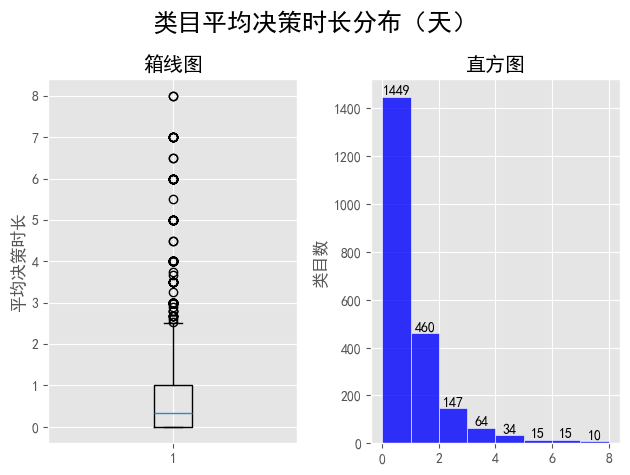

In [63]:
fig,ax=plt.subplots(1,2)
fig.suptitle('类目平均决策时长分布（天）',fontsize=18,fontweight='bold')

ax[0].boxplot(category_time_avg['buy_time'])
ax[0].set_title('箱线图')
ax[0].set_ylabel('平均决策时长')

ax[1].hist(category_time_avg['buy_time'],bins=range(9),edgecolor='white',linewidth=0.5,alpha=0.8,color='blue')
ax[1].bar_label(ax[1].containers[0],fmt='%d')
ax[1].set_title('直方图')
ax[1].set_ylabel('类目数')

plt.tight_layout()
plt.show()

In [64]:
print('类目平均决策时长分析：\n',
      '1、大部分类目的平均决策时长0-1天，即当天完成浏览-消费下单，类目数占比66.04%；\n',
          ' ●这类类目用户决策快，可强化“即时转化”策略，如限时折扣、一键下单、库存紧张提示，快速促成交易；\n',
      '2、决策时长在3天以上的类目数量较少，说明少数类目用户决策周期较长；\n',
          ' ●需通过多触点触达，如收藏后推送优惠、加购后降价或满减提醒、个性化内容种草等来降低决策成本，缩短决策周期；\n',
          ' ●分析长决策时长类目的品类特性，匹配对应的信任背书内容（如用户评价、专业测评）；\n',
          ' ●针对长决策时长类目设计差异化运营方案，避免统一策略导致转化流失；')

类目平均决策时长分析：
 1、大部分类目的平均决策时长0-1天，即当天完成浏览-消费下单，类目数占比66.04%；
  ●这类类目用户决策快，可强化“即时转化”策略，如限时折扣、一键下单、库存紧张提示，快速促成交易；
 2、决策时长在3天以上的类目数量较少，说明少数类目用户决策周期较长；
  ●需通过多触点触达，如收藏后推送优惠、加购后降价或满减提醒、个性化内容种草等来降低决策成本，缩短决策周期；
  ●分析长决策时长类目的品类特性，匹配对应的信任背书内容（如用户评价、专业测评）；
  ●针对长决策时长类目设计差异化运营方案，避免统一策略导致转化流失；


#### 5.2.6 关联购买产品

In [65]:
# 每个用户一个时间戳下的购买产品种类（也就是每笔订单中都是哪些产品）
cross_1=df.groupby(['user_id','timestamp','product_id']).size().reset_index()
cross_2=df.groupby(['user_id','timestamp','product_id']).size().reset_index()

# 表连接，获取关联产品
cross_sell=pd.merge(cross_1,cross_2,on=['user_id','timestamp'],how='left',suffixes=('_1','_2'))

#   筛选product_id_1与product_id_2不同的记录 以及 筛选a_b 组合与b_a组合相同的重复记录
cross=cross_sell[cross_sell['product_id_1']<cross_sell['product_id_2']]

# 关联购买商品分组计数
cross_group=cross.groupby(['product_id_1','product_id_2']).size().reset_index(name='count')
cross_group=cross_group.sort_values('count',ascending=False).head(10)

In [66]:
print(f'\n5.2.6、关联购买产品组合top 10：\n{cross_group.to_string(index=False)}')

print('5.2.6、关联购买产品组合分析：\n',
      '1、核心关联产品：3995514与4139651的关联购买次数最高（25次），且这两个产品分别与4753343形成关联组合（分别15和14次），说明3995514、4139651、4753343是一组高关联度的产品；\n',
          ' ●可设置组合套餐（如三款产品打包优惠）提升客单价；\n',
          ' ●在产品详情页添加“常一起购买”的关联推荐，强化交叉销售；\n',
          ' ●产品广告推荐位关联,促进关联产品转化；\n',
      '2、其他关联组合的关联次数均为(4-10)次，属于中度关联组合;\n',
          ' ●测试“关联推荐位”的广告位展示优先级效果，观察是否能提升关联购买次数；\n',
          ' ●分析这两组产品的用户群体特征，匹配对应的营销活动，增强关联消费意愿；')


5.2.6、关联购买产品组合top 10：
 product_id_1  product_id_2  count
      3995514       4139651     25
      4139651       4753343     15
      3995514       4753343     14
      1954678       2405647     10
      3815697       3817741     10
       327455       4880707      6
      1257878       1358994      6
      3589114       4936201      6
      2869062       3777834      5
       718440       1612243      4
5.2.6、关联购买产品组合分析：
 1、核心关联产品：3995514与4139651的关联购买次数最高（25次），且这两个产品分别与4753343形成关联组合（分别15和14次），说明3995514、4139651、4753343是一组高关联度的产品；
  ●可设置组合套餐（如三款产品打包优惠）提升客单价；
  ●在产品详情页添加“常一起购买”的关联推荐，强化交叉销售；
  ●产品广告推荐位关联,促进关联产品转化；
 2、其他关联组合的关联次数均为(4-10)次，属于中度关联组合;
  ●测试“关联推荐位”的广告位展示优先级效果，观察是否能提升关联购买次数；
  ●分析这两组产品的用户群体特征，匹配对应的营销活动，增强关联消费意愿；


In [67]:
"""
项目完整总结
本项目以百万级电商用户行为数据为基础，通过 Python 完成数据清洗、特征提取、多维度统计分析与可视化，全面洞察电商平台流量规律、用户行为特征、产品 / 品类表现，并输出可落地的运营优化策略。
1. 流量层面
双 12 预热期PV/UV 较平日提升约 24%，流量增长显著；
流量呈日 / 小时周期性：周末 > 工作日、晚间 18:00–22:00 为高峰；
大促吸引大量新客 / 回流客，访问深度略有下降。
2. 用户行为与转化
核心转化路径为：浏览→加购→购买，加购是关键节点；
浏览→加购转化率6.15%，浏览→购买仅2.26%，漏斗衰减严重；
加购→购买转化率36.65%，仍有较大提升空间；
双 12 预热期用户加购前置、购买后置，观望情绪明显。
3. 用户价值与留存
购买用户占比68.68%，复购用户占比66.21%，复购基础良好；
平均购买周期2.39 天，超 60% 用户 1–2 天复购；
大促预热使次日留存从 78% 升至 98.3%，活动拉动极强；
基于 RFM 完成 8 类用户分层，可实现精细化运营。
4. 产品与品类
产品销量极度集中，75% 商品销量仅 1 件；
品类销量两极分化，头部品类拉动整体业绩；
高销量≠高购买率，低销量高转化品类具备增长潜力；
66% 类目当天决策下单，少数类目需长周期种草；
挖掘出高频关联商品组合，可用于提升客单价。
5. 整体结论与价值
项目完整实现了从数据到洞察，从洞察到决策的分析流程，清晰定位流量、转化、用户、商品四大核心问题，输出的优化建议可直接用于：
提升加购率、购买转化率、复购率
优化大促节奏与流量投放
实现用户分层运营与品类资源倾斜
打造关联销售与爆款商品"""

'\n项目完整总结\n本项目以百万级电商用户行为数据为基础，通过 Python 完成数据清洗、特征提取、多维度统计分析与可视化，全面洞察电商平台流量规律、用户行为特征、产品 / 品类表现，并输出可落地的运营优化策略。\n1. 流量层面\n双 12 预热期PV/UV 较平日提升约 24%，流量增长显著；\n流量呈日 / 小时周期性：周末 > 工作日、晚间 18:00–22:00 为高峰；\n大促吸引大量新客 / 回流客，访问深度略有下降。\n2. 用户行为与转化\n核心转化路径为：浏览→加购→购买，加购是关键节点；\n浏览→加购转化率6.15%，浏览→购买仅2.26%，漏斗衰减严重；\n加购→购买转化率36.65%，仍有较大提升空间；\n双 12 预热期用户加购前置、购买后置，观望情绪明显。\n3. 用户价值与留存\n购买用户占比68.68%，复购用户占比66.21%，复购基础良好；\n平均购买周期2.39 天，超 60% 用户 1–2 天复购；\n大促预热使次日留存从 78% 升至 98.3%，活动拉动极强；\n基于 RFM 完成 8 类用户分层，可实现精细化运营。\n4. 产品与品类\n产品销量极度集中，75% 商品销量仅 1 件；\n品类销量两极分化，头部品类拉动整体业绩；\n高销量≠高购买率，低销量高转化品类具备增长潜力；\n66% 类目当天决策下单，少数类目需长周期种草；\n挖掘出高频关联商品组合，可用于提升客单价。\n5. 整体结论与价值\n项目完整实现了从数据到洞察，从洞察到决策的分析流程，清晰定位流量、转化、用户、商品四大核心问题，输出的优化建议可直接用于：\n提升加购率、购买转化率、复购率\n优化大促节奏与流量投放\n实现用户分层运营与品类资源倾斜\n打造关联销售与爆款商品'